In [ ]:
#importing all the important library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading dataset
df = pd.read_excel("../datasets/amazon.csv.xlsx")
df.head()

In [ ]:
#printing the shape
df.shape


(1465, 4)

In [13]:
#printig the column
df.columns

Index(['rating', 'rating_count', 'review_title', 'review_content'], dtype='str')

In [14]:
#checking info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rating          1465 non-null   object
 1   rating_count    1463 non-null   object
 2   review_title    1465 non-null   str   
 3   review_content  1465 non-null   str   
dtypes: object(2), str(2)
memory usage: 2.3+ MB


In [15]:
#checking null values
df.isnull().sum()

rating            0
rating_count      2
review_title      0
review_content    0
dtype: int64

In [19]:
# remove missing value
df[df['rating_count'].isnull()]
df = df.dropna(subset=['rating_count'])
#checking again missing value
df.isnull().sum()

rating            0
rating_count      0
review_title      0
review_content    0
dtype: int64

In [20]:
# keeping imp column
df = df[
    [
        "rating",
        "rating_count",
        "review_title",
        "review_content"
    ]
]

In [22]:
#combine review_title and review_content as review
df["review"] = (
    df["review_title"] + " " + df["review_content"]
)

df["review"].head()

0    Satisfied,Charging is really fast,Value for mo...
1    A Good Braided Cable for Your Type C Device,Go...
2    Good speed for earlier versions,Good Product,W...
3    Good product,Good one,Nice,Really nice product...
4    As good as original,Decent,Good one for second...
Name: review, dtype: str

In [23]:
#removing duplicates values
df.drop_duplicates(
    subset=["review"],
    inplace=True
)

In [24]:
#clean rating column (rating may contains strings)
df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

In [ ]:
#checking the rating 
df["rating"].describe()

count    1209.000000
mean        4.085194
std         0.304852
min         2.000000
25%         3.900000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating, dtype: float64

In [34]:
sorted(df["rating"].unique())

[np.float64(2.0),
 np.float64(2.3),
 np.float64(2.6),
 np.float64(2.8),
 np.float64(2.9),
 np.float64(3.0),
 np.float64(3.1),
 np.float64(3.2),
 np.float64(3.3),
 np.float64(3.4),
 np.float64(3.5),
 np.float64(3.6),
 np.float64(3.7),
 np.float64(3.8),
 np.float64(3.9),
 np.float64(4.0),
 np.float64(4.1),
 np.float64(4.2),
 np.float64(4.3),
 np.float64(4.4),
 np.float64(4.5),
 np.float64(4.6),
 np.float64(4.7),
 np.float64(4.8),
 np.float64(5.0),
 np.float64(nan)]

In [35]:
df["rating"].max()

np.float64(5.0)

In [37]:
# CREATE SENTIMENT COLUMN (1-4 Negative,5-6 Neutral,7-10 positive)
def convert_sentiment(rating):

    if rating >= 4.0:
        return "Positive"

    elif rating >= 3.0:
        return "Neutral"

    else:
        return "Negative"
# using these function to convert these
df["sentiment"] = df["rating"].apply(
    convert_sentiment
)

In [38]:
#add a domain column
df["domain"] = "ecommerce"

In [39]:
# Creating standard formate
amazon_df = df[
    [
        "review",
        "sentiment",
        "domain",
        "rating"
    ]
]

In [40]:
#checking the amazon new standard dataset
amazon_df.head()

,review,sentiment,domain,rating
0,"Satisfied,Charging is really fast,Value for mo...",Positive,ecommerce,4.2
1,"A Good Braided Cable for Your Type C Device,Go...",Positive,ecommerce,4.0
2,"Good speed for earlier versions,Good Product,W...",Neutral,ecommerce,3.9
3,"Good product,Good one,Nice,Really nice product...",Positive,ecommerce,4.2
4,"As good as original,Decent,Good one for second...",Positive,ecommerce,4.2


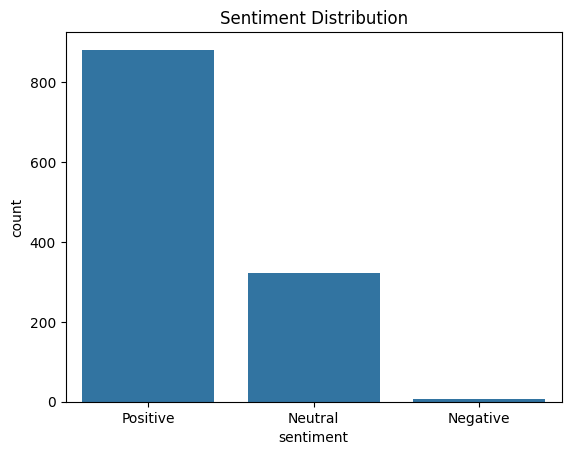

In [41]:
##Basic EDA
# Sentiment distribution 
sns.countplot(
    x="sentiment",
    data=amazon_df
)

plt.title("Sentiment Distribution")

plt.show()

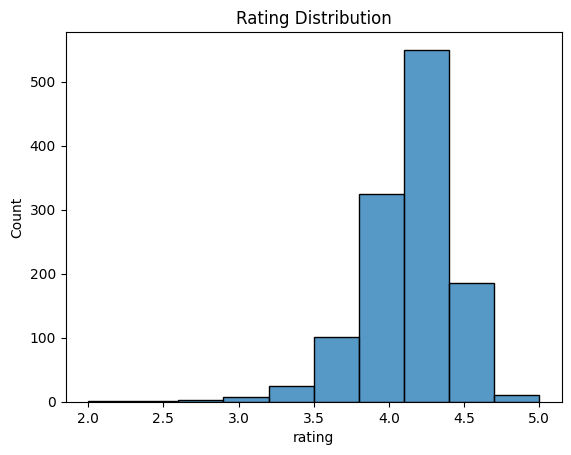

In [ ]:
#rating distribution
sns.histplot(
    amazon_df["rating"],
    bins=10
)

plt.title("Rating Distribution")

plt.show()

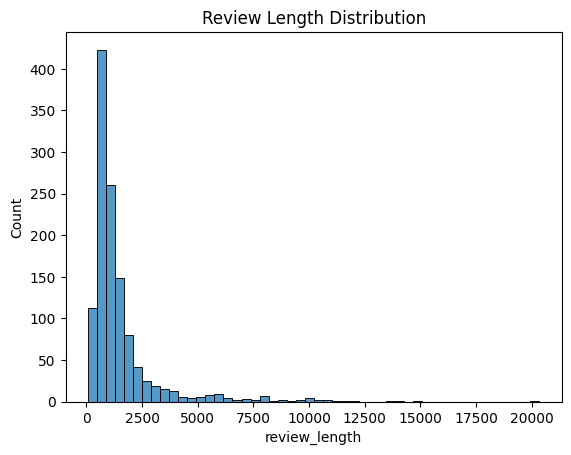

In [44]:
amazon_df["review_length"] = (
    amazon_df["review"].apply(len)
)
sns.histplot(
    amazon_df["review_length"],
    bins=50
)

plt.title("Review Length Distribution")

plt.show()

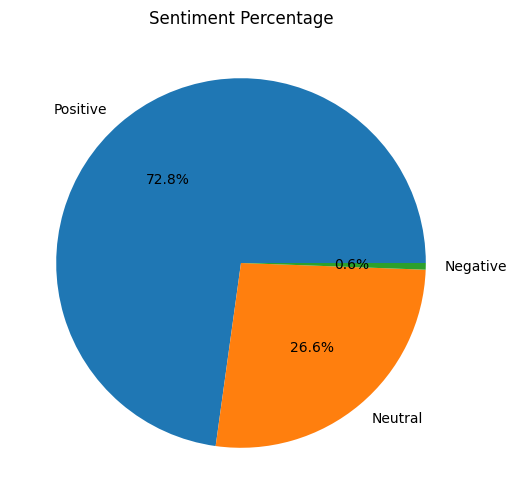

In [45]:
amazon_df["sentiment"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sentiment Percentage")

plt.ylabel("")

plt.show()

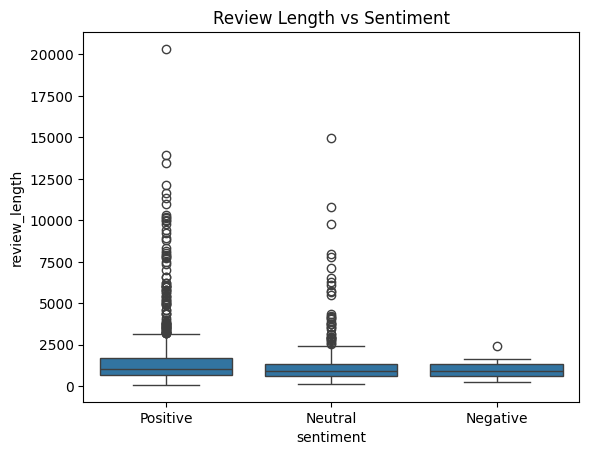

In [46]:
sns.boxplot(
    x="sentiment",
    y="review_length",
    data=amazon_df
)

plt.title("Review Length vs Sentiment")

plt.show()

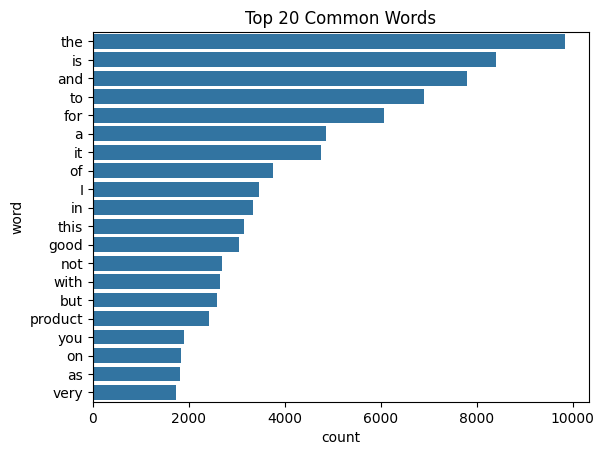

In [47]:
from collections import Counter
all_words = " ".join(
    amazon_df["review"]
).split()
common_words = Counter(
    all_words
).most_common(20)
common_df = pd.DataFrame(
    common_words,
    columns=["word", "count"]
)
sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title("Top 20 Common Words")

plt.show()

In [48]:
positive_text = " ".join(
    amazon_df[
        amazon_df["sentiment"] == "Positive"
    ]["review"]
)

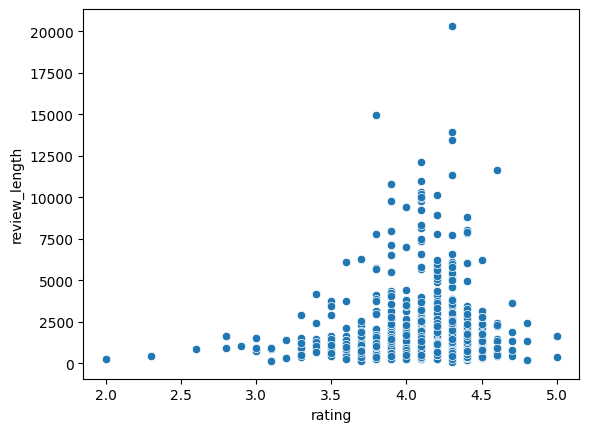

In [49]:
sns.scatterplot(
    x="rating",
    y="review_length",
    data=amazon_df
)

plt.show()

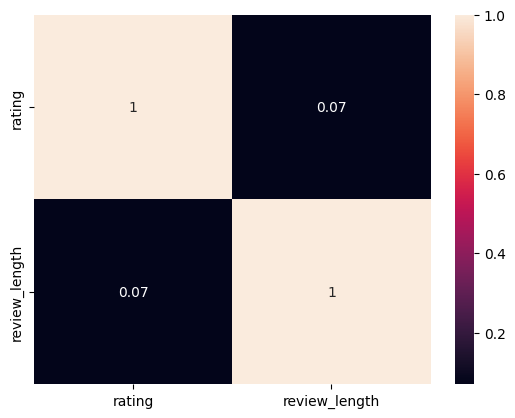

In [50]:
numeric_df = amazon_df.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

In [ ]:
# Now we will do Text preprocessing (NLP preprocessing)
#import library
import re
import nltk
# download NLTK data
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/anthony/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/anthony/nltk_data...
[nltk_data] Downloading package omw-1.4 to /home/anthony/nltk_data...


True

In [53]:
# import NLP tools
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [54]:
#CREATE STOPWORDS + LEMMATIZER
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

In [59]:
#cleaning function
def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove html tags
    text = re.sub(r"<.*?>", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation/special chars
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # tokenize
    words = text.split()

    # remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # join cleaned words
    return " ".join(words)



In [60]:
#apply cleaning
amazon_df["clean_review"] = (
    amazon_df["review"]
    .apply(clean_text)
)

In [ ]:
#checking values after cleaning
amazon_df[
    ["review", "clean_review"]
].head()

,review,clean_review
0,"Satisfied,Charging is really fast,Value for mo...",satisfied charging really fast value money pro...
1,"A Good Braided Cable for Your Type C Device,Go...",good braided cable type c device good quality ...
2,"Good speed for earlier versions,Good Product,W...",good speed earlier version good product workin...
3,"Good product,Good one,Nice,Really nice product...",good product good one nice really nice product...
4,"As good as original,Decent,Good one for second...",good original decent good one secondary use be...


In [63]:
#check empty review
amazon_df[
    amazon_df["clean_review"] == ""
]

,review,sentiment,domain,rating,review_length,clean_review


In [64]:
#remove empty review
amazon_df = amazon_df[
    amazon_df["clean_review"] != ""
]

In [ ]:
# CREATE CLEANED WORDCLOUD
#import the library
from wordcloud import WordCloud

In [ ]:
#combine the text
text = " ".join(
    amazon_df["clean_review"]
)

In [ ]:
#create the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

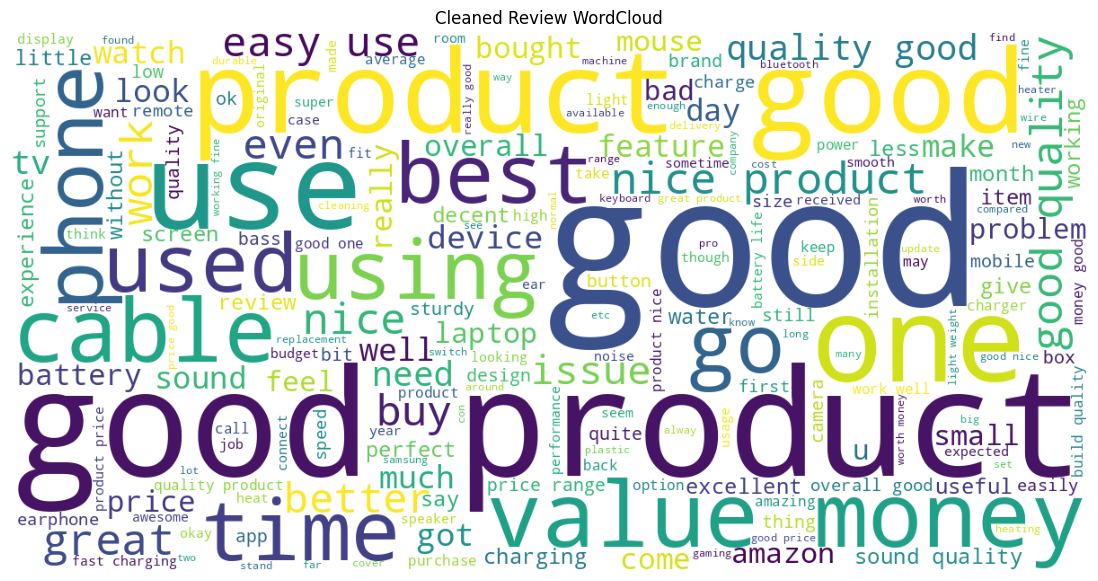

In [ ]:
#plot
plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Cleaned Review WordCloud")
plt.show()

In [74]:
#MOST COMMON CLEANED WORDS
from collections import Counter

In [ ]:
#extract words
all_words = " ".join(
    amazon_df["clean_review"]
).split()

In [ ]:
#Count Words
common_words = Counter(
    all_words
).most_common(20)

In [ ]:
#Convert To DataFrame
common_df = pd.DataFrame(
    common_words,
    columns=["word", "count"]
)

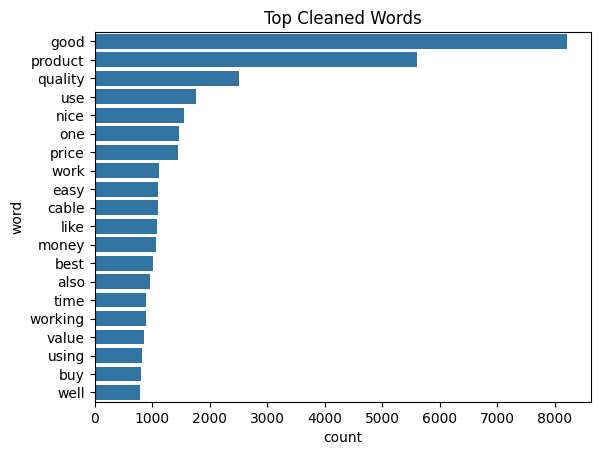

In [ ]:
#Plot
sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title("Top Cleaned Words")

plt.show()

In [75]:
#SAVE FINAL AMAZON DATASET
amazon_df.to_csv(
    "../processed_data/amazon_processed.csv",
    index=False
)